- Shuffle sequences 

In [1]:
import random

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import numpy as np
from matplotlib import pyplot as plt    

import optax
import equinox as eqx 
from jax import Array, numpy as jnp, random as jr, nn

from qwen import QwenModel, utils, generate, forward

In [2]:
def load_dataset(seq_len: int):
    loaded_data = np.load("data.npz")

    probs = [loaded_data["probs0"], loaded_data["probs1"], loaded_data["probs2"]]
    rewards = loaded_data["rewards"]
    actions = loaded_data["actions"]

    probs = [jnp.array(p) for p in probs]
    probs = [jnp.argmax(p, axis=-1) for p in probs]


    rewards = jnp.array(rewards)
    actions = jnp.array(actions)

    reward_ids = jnp.argmax(rewards, axis=-1)
    action_ids = jnp.argmax(actions, axis=-1)

    N = reward_ids.shape[0]
    split = int(0.9 * N)  

    train_probs = [p[:split] for p in probs]
    test_probs = [p[split:] for p in probs]

    train_rewards, test_rewards = reward_ids[:split], reward_ids[split:]
    train_actions, test_actions = action_ids[:split], action_ids[split:]

    B = train_rewards.shape[0] // seq_len  
    L = B * seq_len  

    train_probs = [p[:L].reshape(1, B, seq_len) for p in train_probs]
    train_rewards = train_rewards[:L].reshape(1, B, seq_len)
    train_actions = train_actions[:L].reshape(1, B, seq_len)

    probs_inputs = [p[:, :, :-1] for p in train_probs]
    probs_targets = [p[:, :, 1:] for p in train_probs]

    reward_inputs, reward_targets = train_rewards[:, :, :-1], train_rewards[:, :, 1:]
    action_inputs, action_targets = train_actions[:, :, :-1], train_actions[:, :, 1:]

    return (
        probs_inputs[0], probs_inputs[1], probs_inputs[2],
        probs_targets[0], probs_targets[1], probs_targets[2],
        action_inputs, action_targets,
        reward_inputs, reward_targets,
        test_probs[0], test_probs[1], test_probs[2],
        test_actions, test_rewards,
    )


In [3]:
import optax
import equinox as eqx
import jax.numpy as jnp


def train_model(
    model,
    obj1_inputs,
    obj2_inputs,
    obj3_inputs,
    action_inputs,
    obj1_targets,
    obj2_targets,
    obj3_targets,
    reward_targets,
    obj1_size,
    obj2_size,
    obj3_size,
    reward_size,
    callback,
    epochs,
    warmup_steps=2000,
):
    total_steps = epochs * len(obj1_inputs)

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=1e-4,
        warmup_steps=warmup_steps,
        decay_steps=total_steps,
        end_value=1e-6,
    )
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(schedule, b1=0.9, b2=0.98, weight_decay=0.01),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(
        model,
        obj1_ids,
        obj2_ids,
        obj3_ids,
        action_ids,
        tgt_obj1,
        tgt_obj2,
        tgt_obj3,
        tgt_rewards,
    ):
        logits = forward(model, obj1_ids, obj2_ids, obj3_ids, action_ids)

        logits_obj1, logits_obj2, logits_obj3, logits_rewards = jnp.split(
            logits,
            [obj1_size, obj1_size + obj2_size, obj1_size + obj2_size + obj3_size],
            axis=-1,
        )

        loss_obj1 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj1, tgt_obj1
        )
        loss_obj2 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj2, tgt_obj2
        )
        loss_obj3 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj3, tgt_obj3
        )
        loss_rewards = optax.softmax_cross_entropy_with_integer_labels(
            logits_rewards, tgt_rewards
        )   

        return (loss_obj1 + loss_obj2 + loss_obj3 + loss_rewards).mean()

    @eqx.filter_jit
    def step(
        model,
        opt_state,
        obj1_ids,
        obj2_ids,
        obj3_ids,
        action_ids,
        tgt_obj1,
        tgt_obj2,
        tgt_obj3,
        tgt_rewards,
    ):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(
            model,
            obj1_ids,
            obj2_ids,
            obj3_ids,
            action_ids,
            tgt_obj1,
            tgt_obj2,
            tgt_obj3,
            tgt_rewards,
        )
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    for epoch in range(epochs):
        total_loss = 0.0

        for (
            batch_obj1,
            batch_obj2,
            batch_obj3,
            batch_action,
            batch_tgt1,
            batch_tgt2,
            batch_tgt3,
            batch_tgt_rewards,
        ) in zip(
            obj1_inputs,
            obj2_inputs,
            obj3_inputs,
            action_inputs,
            obj1_targets,
            obj2_targets,
            obj3_targets,
            reward_targets,
        ):
            model, opt_state, loss = step(
                model,
                opt_state,
                batch_obj1,
                batch_obj2,
                batch_obj3,
                batch_action,
                batch_tgt1,
                batch_tgt2,
                batch_tgt3,
                batch_tgt_rewards,
            )
            total_loss += loss

        if epoch % 100 == 0:
            callback(model, total_loss / len(obj1_inputs))

    return model

def evaluate(
    model,
    test_obj1,
    test_obj2,
    test_obj3,
    test_actions,
    test_rewards,
    obj1_size,
    obj2_size,
    obj3_size,
    reward_size,
    context_len=64,
    max_tokens=64,
):
    start = random.randint(0, test_obj1.shape[0] - max_tokens - context_len)

    true_obj1_seq = test_obj1[start : start + context_len + max_tokens]
    true_obj2_seq = test_obj2[start : start + context_len + max_tokens]
    true_obj3_seq = test_obj3[start : start + context_len + max_tokens]
    true_action_seq = test_actions[start : start + context_len + max_tokens]
    true_reward_seq = test_rewards[start : start + context_len + max_tokens]

    context_obj1 = true_obj1_seq[:context_len]
    context_obj2 = true_obj2_seq[:context_len]
    context_obj3 = true_obj3_seq[:context_len]

    gen_obj1, gen_obj2, gen_obj3, gen_rewards = generate(
        model,
        obj1_tokens=jnp.array([context_obj1]),
        obj2_tokens=jnp.array([context_obj2]),
        obj3_tokens=jnp.array([context_obj3]),
        action_tokens=jnp.array([true_action_seq]),
        obj1_size=obj1_size,
        obj2_size=obj2_size,
        obj3_size=obj3_size,
        reward_size=reward_size,
        max_tokens=max_tokens,
    )

    gen_obj1, gen_obj2, gen_obj3, gen_rewards = (
        gen_obj1.squeeze(),
        gen_obj2.squeeze(),
        gen_obj3.squeeze(),
        gen_rewards.squeeze(),
    )

    fig, axes = plt.subplots(4, 1, figsize=(6, 8))

    true_obj1_seq = true_obj1_seq[context_len:]
    true_obj2_seq = true_obj2_seq[context_len:]
    true_obj3_seq = true_obj3_seq[context_len:]
    true_reward_seq = true_reward_seq[context_len:]

    gen_obj1 = gen_obj1[context_len:]
    gen_obj2 = gen_obj2[context_len:]
    gen_obj3 = gen_obj3[context_len:]
    gen_rewards = gen_rewards 

    axes[0].plot(range(len(gen_obj1)), gen_obj1, label="gen obj1")
    axes[0].plot(range(len(true_obj1_seq)), true_obj1_seq, label="true obj1")
    axes[0].set_title("Object 1")
    axes[0].legend()

    axes[1].plot(range(len(gen_obj2)), gen_obj2, label="gen obj2")
    axes[1].plot(range(len(true_obj2_seq)), true_obj2_seq, label="true obj2")
    axes[1].set_title("Object 2")
    axes[1].legend()

    axes[2].plot(range(len(gen_obj3)), gen_obj3, label="gen obj3")
    axes[2].plot(range(len(true_obj3_seq)), true_obj3_seq, label="true obj3")
    axes[2].set_title("Object 3")
    axes[2].legend()

    axes[3].plot(range(len(gen_rewards)), gen_rewards, label="gen rewards")
    axes[3].plot(range(len(true_reward_seq)), true_reward_seq, label="true rewards")
    axes[3].set_title("Rewards")
    axes[3].legend()

    plt.tight_layout()
    plt.show()

12.280897


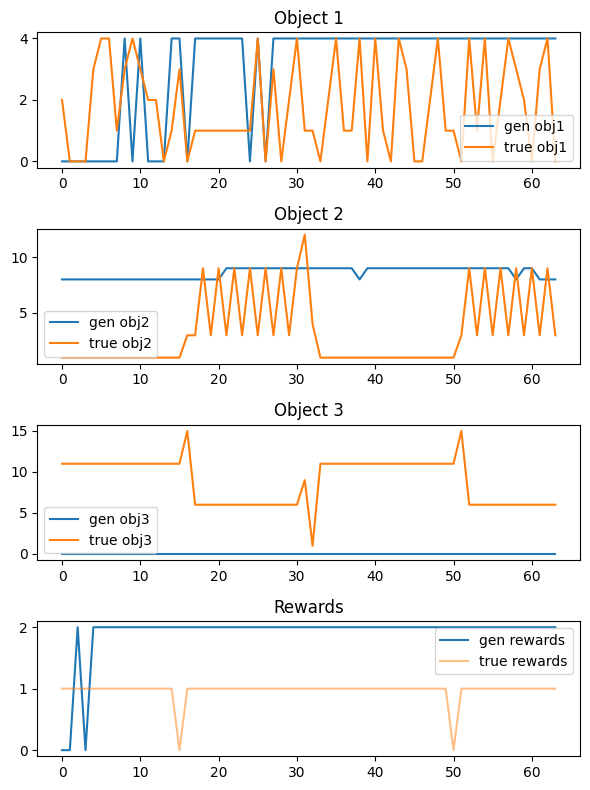

In [4]:
key = jr.PRNGKey(0)
(
    obj1_inputs,
    obj2_inputs,
    obj3_inputs,
    obj1_targets,
    obj2_targets,
    obj3_targets,
    action_inputs,
    action_targets,
    reward_inputs,
    reward_targets,
    test_obj1,
    test_obj2,
    test_obj3,
    test_actions,
    test_rewards,
) = load_dataset(128)

object1_size = 5
object2_size = 16
object3_size = 16
reward_size = 3
action_size = 3

model = utils.init(
    key,
    object1_size=object1_size,
    object2_size=object2_size,
    object3_size=object3_size,
    action_size=action_size,
    reward_size=reward_size,
    embed_dim_per_field=32,
    hidden_size=128,
    num_layers=4,
    num_heads=4,
    num_key_value_heads=4,
    rope_theta=10000.0,
    rms_norm_eps=1e-6,
)


def eval_callback(model, loss):
    print(loss)
    evaluate(
        model,
        test_obj1,
        test_obj2,
        test_obj3,
        test_actions,
        test_rewards,
        object1_size,
        object2_size,
        object3_size,
        reward_size,
        context_len=64,
        max_tokens=64,
    )

model = train_model(
    model,
    obj1_inputs,
    obj2_inputs,
    obj3_inputs,
    action_inputs,
    obj1_targets,
    obj2_targets,
    obj3_targets,
    reward_targets,
    object1_size,
    object2_size,
    object3_size,
    reward_size,
    eval_callback,
    epochs=10000,
)
